# Data Pipeline — LayerZero Sybil Detection

**Purpose**: Build the master feature DataFrame used across all Sybil detection models.
Runs end-to-end from raw CSV files to labelled, split, balanced NumPy arrays.

**Output files** (written to `OUTPUT_DIR`):
| File | Contents |
|---|---|
| `master_df.parquet` | All 434k addresses × 63 features + label columns |
| `splits.npz` | `X_train`, `X_val`, `X_test`, `y_train`, `y_val`, `y_test` (float32) |
| `feature_list.json` | Ordered list of 63 feature names |

**Seven pipeline steps:**
1. L0 base features (transaction + bridge metrics)
2. Gas provision mapping (child → parent address graph)
3. Labeled anchor streaming (9M entity set, memory-efficient)
4. Tree / topology features (gas provision network structure)
5. CEX / DEX in-degree counts
6. Sybil ground-truth labels + `is_provider` flag
7. Chain traversal (`chain_length`, `interactors_in_chain`)

Then: taxonomy, funding groups, and the train / validation / test split (`SPLIT_METHOD`).
The step functions live in `sybil_pipeline.py`, which the model notebooks also import.

---
*Reference paper*: Sybil Detection on Public Blockchains via XGBoost and
Gas Provision Network Analysis (Imig et al., 2025)

## Setup

In [1]:
import os, time, gc, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import sybil_pipeline as sp
warnings.filterwarnings('ignore')

print('pandas', pd.__version__, '| numpy', np.__version__)

pandas 3.0.6 | numpy 2.4.6


In [2]:
# ── Adjust these two paths ────────────────────────────────────
DATA_DIR   = './data'     # folder containing all input CSV files
OUTPUT_DIR = './output'   # folder for master_df.parquet and splits.npz
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 'group'  = stratified group split by funding cluster (revision default)
# 'random' = address-level split used in the original paper
SPLIT_METHOD = os.environ.get('SPLIT_METHOD', 'group')

P     = sp.data_paths(DATA_DIR)   # input file paths
FEATS = sp.FEATS                  # 63 features, chosen manually by the authors
SEED  = sp.SEED
print(f'DATA_DIR     : {DATA_DIR}')
print(f'OUTPUT_DIR   : {OUTPUT_DIR}')
print(f'SPLIT_METHOD : {SPLIT_METHOD}')
print(f'Features     : {len(FEATS)} selected')

DATA_DIR     : ./data
OUTPUT_DIR   : ./output
SPLIT_METHOD : group
Features     : 63 selected


## Step 1 — L0 Base Features

Five CSV files (100 k rows each) covering every Ethereum address that interacted with the
LayerZero endpoint before the May 1 2024 snapshot.

**Columns provided (~56):** LayerZero transaction metrics, Ethereum in/out transaction stats,
cross-chain bridge activity, Stargate swap amounts.

**Cleaning applied:**
- Drop the burn address `0x0000...0000`
- Drop `in_degree`, `out_degree`, `rank` (not in selected feature set)
- Drop rows that are all-NaN except the address column
- Deduplicate on `addr` (keep first)

In [3]:
t0 = time.time()
df = sp.load_l0(P['l0'])
print(f'After cleaning   : {len(df):,} rows')
print(f'Columns          : {len(df.columns)}')
print(f'Time             : {time.time()-t0:.1f}s')

After cleaning   : 434,786 rows
Columns          : 55
Time             : 4.3s


In [4]:
# ── Quick column inventory ────────────────────────────────────
col_df = pd.DataFrame({
    'Column'   : df.columns,
    'Dtype'    : df.dtypes.values,
    'NullPct'  : (df.isnull().mean() * 100).round(2).values,
    'InFEATS'  : [c in FEATS for c in df.columns],
})
print('Columns in L0 features:')
print(col_df.to_string(index=False))

Columns in L0 features:
                              Column   Dtype  NullPct  InFEATS
                                addr     str     0.00    False
                  n_eth_interactions float64     0.00     True
                  n_l0_source_chains float64     0.00     True
                    n_l0_dest_chains float64     0.00    False
    n_l0_dest_chain_per_source_chain float64     0.00    False
                       n_l0_projects float64     0.00     True
       n_l0_project_per_source_chain float64     0.00     True
               n_l0_source_contracts float64     0.00     True
                 n_l0_dest_contracts float64     0.00    False
                l0_max_stargate_swap float64     0.00    False
                l0_avg_stargate_swap float64     0.00     True
                l0_min_stargate_swap float64     0.00     True
              l0_max_native_drop_usd float64     0.00    False
              l0_avg_native_drop_usd float64     0.00    False
                            n_l

## Step 2 — Gas Provision Mapping

Builds `tfm: activated_address → gas_provider` from the gas provision network file.
Each edge records which address first sent ETH to another address, enabling on-chain activity.

**Temporal cutoff.** The LayerZero snapshot table ends at 2024-05-01 23:59:59 UTC (the latest
L0 transaction in the data). Edges dated at or after `sp.SNAPSHOT_END` (2024-05-02 00:00 UTC)
are dropped here, before any provider, chain, tree, or group feature is computed. The source
query (`data/20241114_gas_provision/readme.txt`) has no date filter, so this cutoff is applied
in code.

This mapping is used for:
- Computing `provider_*` and tree features (Step 4)
- Chain traversal (Step 7) and funding groups

In [5]:
t0 = time.time()
funding = sp.load_provision(P['gas_prov'])   # edges before sp.SNAPSHOT_END only
tfm  = sp.provision_map(funding)
pset = set(tfm.values())   # all provider addresses

print(f'Snapshot cutoff         : {sp.SNAPSHOT_END} UTC (exclusive)')
print(f'Edges dropped (later)   : {funding.attrs["n_after_cutoff"]:,}')
print(f'Latest edge kept        : {funding.attrs["max_time"]}')
print(f'Valid mappings          : {len(tfm):,}')
print(f'Unique provider addrs   : {len(pset):,}')
cov = df['addr'].isin(set(tfm))
print(f'L0 addresses covered    : {cov.sum():,} ({cov.mean()*100:.1f}%)')
print(f'Time : {time.time()-t0:.1f}s')

Valid mappings          : 604,661
Unique provider addrs   : 202,899


L0 addresses covered    : 434,110 (99.8%)
Time : 6.5s


Provider fan-out distribution:
count    202899.00
mean          2.98
std         129.23
min           1.00
25%           1.00
50%           1.00
75%           1.00
max       19022.00
Name: fan_out, dtype: float64

Providers funding ≥ 100 wallets : 235
Providers funding ≥  10 wallets : 1,194
Providers funding    1 wallet   : 188,907


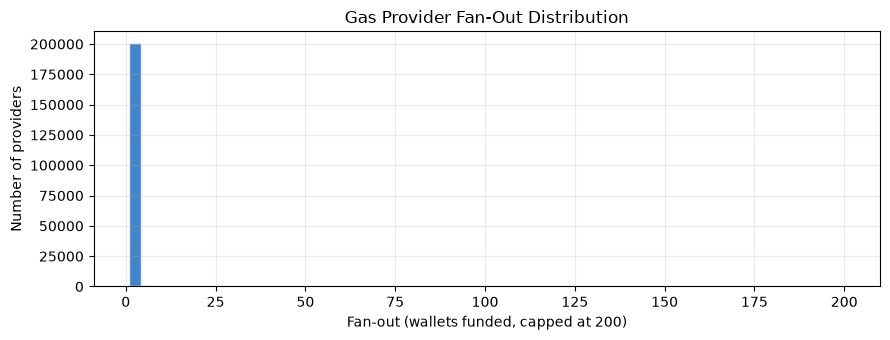

In [6]:
# ── Fan-out distribution (how many wallets each provider funded) ──
from collections import Counter
fan_out = Counter(tfm.values())
fo_series = pd.Series(list(fan_out.values()), name='fan_out')

print('Provider fan-out distribution:')
print(fo_series.describe().round(2))
print(f'\nProviders funding ≥ 100 wallets : {(fo_series >= 100).sum():,}')
print(f'Providers funding ≥  10 wallets : {(fo_series >= 10).sum():,}')
print(f'Providers funding    1 wallet   : {(fo_series == 1).sum():,}')

fig, ax = plt.subplots(figsize=(9, 3.5))
fo_series.clip(upper=200).hist(bins=60, ax=ax, color='#1565C0', alpha=0.8, edgecolor='white')
ax.set(xlabel='Fan-out (wallets funded, capped at 200)', ylabel='Number of providers',
       title='Gas Provider Fan-Out Distribution')
ax.grid(alpha=0.25); plt.tight_layout(); plt.show()

## Step 3 — Labeled Anchors

A labeled address is a known shared service (exchange, DEX, bridge, relayer, protocol contract), so
the trace of who funded a wallet stops there. The labeled set follows one rule
(`sp.stream_labeled_anchors`, docs/REVISION_LEAKAGE.md item A12):

1. **Public label datasets**: the consolidated 2024 label file (without its hand-added addresses),
   plus Dune Spellbook's CEX, DEX and bridge lists at pinned commits
   (`data/20260128_dune_spellbook_labels/`).
2. **Etherscan check**: every other address that funded at least 50 LayerZero interactors was looked
   up on Etherscan and labeled if tagged as a shared service
   (`data/20260930_etherscan_service_labels/`).

The 9M-line label file is streamed; only addresses in the provision network are kept.

| Feature | Description |
|---|---|
| `provider_is_labeled` | Provider is a labeled shared service |
| `provider_is_interactor` | Provider itself interacted with LayerZero |
| `provider_is_null` | No gas provider found for this address |

In [7]:
t0 = time.time()
# Stream: only keep provider addresses present in the labeled file
labeled_anchors = sp.stream_labeled_anchors(P, set(tfm) | pset)
print(f'Labeled anchors retained   : {len(labeled_anchors):,}  '
      f'(provision-network addresses that are known entities)')

iset = set(df['addr'])   # all L0 interactor addresses
df = sp.add_provider_flags(df, tfm, labeled_anchors)

print(f'\nprovider_is_labeled    : {df.provider_is_labeled.sum():,} ({df.provider_is_labeled.mean()*100:.1f}%)')
print(f'provider_is_interactor : {df.provider_is_interactor.sum():,} ({df.provider_is_interactor.mean()*100:.1f}%)')
print(f'provider_is_null       : {df.provider_is_null.sum():,} ({df.provider_is_null.mean()*100:.1f}%)')
print(f'Time : {time.time()-t0:.1f}s')

Labeled anchors retained   : 3,698  (providers that are known entities)



provider_is_labeled    : 302,795 (69.6%)
provider_is_interactor : 35,802 (8.2%)
provider_is_null       : 676 (0.2%)
Time : 3.8s


## Step 4 — Provider and Tree / Topology Features

Graph metrics on the gas provision network, computed here from the Step 2 edges (so the
snapshot cutoff applies). Provides structural signals about whether the funding pattern looks
like an industrial Sybil operation (star topology, uniform gas amounts, high branching factor)
vs organic use.

- `provider_*`: statistics of the provider's edges to LayerZero interactors (fan-out, amounts,
  star-pattern flag).
- Tree features: the provision forest drops every edge that touches a labeled address, so an
  interactor's tree is its unlabeled funding cluster. Metrics are computed on the whole tree
  (`tree_size`, `max_depth`, `branching_factor`, `gini_coefficient`, entropy / skewness of gas
  amounts, ...). `depth` is the interactor's distance to the tree root.

The code is `sp.provision_features`, a port of
`data/20241117_tree_features/20241117 Gas Provision Featurization.ipynb`, which produced the
original precomputed file. The regression check below compares the two; every difference is
explained in `docs/REVISION_LEAKAGE.md` (duplicate wallet in the original file, labeled-address
list, snapshot cutoff).

In [8]:
t0 = time.time()
cols_before = set(df.columns)
prov_feats = sp.provision_features(funding, set(df['addr']), labeled_anchors)
df = sp.merge_provision_features(df, prov_feats)
new_cols = [col for col in df.columns if col not in cols_before]
print(f'New columns added : {len(new_cols)}')
print(f'  {new_cols}')
print(f'\nAfter merge : {len(df):,} rows, {len(df.columns)} cols')
print(f'Time        : {time.time()-t0:.1f}s')

# ── Regression check against the original precomputed file ────
cmp, n_common, n_old, n_new = sp.compare_to_precomputed(prov_feats, P['tree_precomputed'])
print(f'\nOriginal file rows (unique addr): {n_old:,} | recomputed: {n_new:,} | common: {n_common:,}')
print('Features that differ from the original file:')
print(cmp[cmp.n_differ > 0].to_string(index=False))

New columns added : 31
  ['provider_fan_out', 'provider_total_gas_provision_amount', 'provider_avg_gas_provision_amount', 'provider_max_gas_provision_amount', 'provider_min_gas_provision_amount', 'provider_is_star_like_attack', 'tree_size', 'total_gas', 'max_depth', 'branching_factor', 'balance_factor', 'leaf_provision_proportion', 'avg_depth', 'depth_variance', 'leaf_to_internal_ratio', 'avg_leaf_gas', 'breadth_factor', 'breadth_to_depth_ratio', 'gini_coefficient', 'gas_distribution_entropy', 'gas_distribution_skewness', 'leaf_gas_distribution_entropy', 'leaf_gas_distribution_skewness', 'sparsity', 'depth', 'longest_chain_ratio', 'star_like_ratio', 'depth_weighted_avg_gas', 'chain_length', 'gas_provision_amount', 'gas_provision_block_number']

After merge : 434,787 rows, 89 cols
Time        : 2.8s


## Step 5 — CEX / DEX In-Degree

Counts how many incoming transactions each address received from centralized exchanges
(`cex_in_count`) and decentralized exchanges (`dex_in_count`).

> **LightGBM gotcha reminder**: if using `subsample < 1.0`, you must also set
> `subsample_freq=1` in LightGBM or bagging is silently disabled.

In [9]:
t0 = time.time()
df = sp.merge_cex_dex(df, P['cex'])
print('cex_in_count stats:')
print(df['cex_in_count'].describe().round(3))
print(f'\nTime : {time.time()-t0:.1f}s')

cex_in_count stats:
count    434787.000
mean          3.212
std           3.503
min           0.000
25%           1.000
50%           2.000
75%           4.000
max          80.000
Name: cex_in_count, dtype: float64

Time : 1.1s


## Step 6 — Sybil Labels + `is_provider`

Ground truth from the LayerZero Foundation's final Sybil list (September 2024 snapshot).

**Label provenance**: multi-stage detection process — Louvain community detection,
proprietary scoring by Nansen and Chaos Labs, self-reporting bounty, and crowdsourced
community challenge.

**`is_provider`**: binary flag set to 1 if this address itself funded another address.
Sybil operators often act as both provider and interactor.

In [10]:
t0 = time.time()
df = sp.add_labels(df, P['sybil'], tfm)

n_sybil = df['sybil'].sum(); n_total = len(df)
print('Label distribution in master df:')
print(f'  Sybil     : {n_sybil:,} ({n_sybil/n_total*100:.2f}%)')
print(f'  Non-Sybil : {n_total-n_sybil:,} ({(n_total-n_sybil)/n_total*100:.2f}%)')
print(f'  is_provider (Sybil)     : {df[df.sybil==1].is_provider.sum():,}')
print(f'  is_provider (Non-Sybil) : {df[df.sybil==0].is_provider.sum():,}')
print(f'Time : {time.time()-t0:.1f}s')

Label distribution in master df:
  Sybil     : 18,211 (4.19%)
  Non-Sybil : 416,576 (95.81%)
  is_provider (Sybil)     : 1,077
  is_provider (Non-Sybil) : 26,903
Time : 2.5s


## Step 7 — Chain Traversal

Walks the gas provision graph upward from each address to the nearest labeled anchor,
computing two features:

| Feature | Description |
|---|---|
| `chain_length` | Hops from this address to the nearest labeled funder |
| `interactors_in_chain` | LayerZero interactors encountered along that chain |

**Algorithm**: iterative while-loop with a visited-set cycle guard.
Terminates when: (a) the next provider is a labeled anchor, (b) the chain ends
(no further provider), or (c) a cycle is detected.

**Complexity**: O(n × d̄) where d̄ ≈ 1.9 hops average — completes in ~2s for 434k addresses.

> The `labeled_anchors` set (≈ 4,200 entries) rather than the full 9M labeled set is
> used for speed. They are logically equivalent: only addresses in the provision network
> can terminate a chain.

In [11]:
t0 = time.time()
df = sp.add_chain_features(df, tfm, labeled_anchors)

print('chain_length stats:')
print(df['chain_length'].describe().round(3))
print('\ninteractors_in_chain stats:')
print(df['interactors_in_chain'].describe().round(3))
print(f'\nTime : {time.time()-t0:.1f}s')

chain_length stats:
count    434787.000
mean          1.876
std           3.463
min           0.000
25%           1.000
50%           1.000
75%           2.000
max         504.000
Name: chain_length, dtype: float64

interactors_in_chain stats:
count    434787.000
mean          1.172
std           1.354
min           1.000
25%           1.000
50%           1.000
75%           1.000
max          94.000
Name: interactors_in_chain, dtype: float64

Time : 1.5s


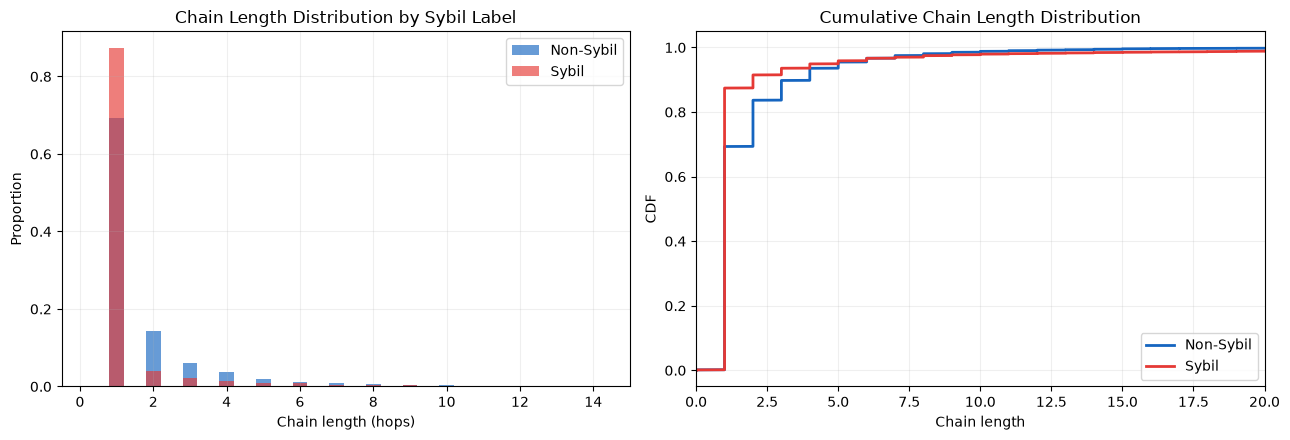

In [12]:
# ── Chain length by Sybil label ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, group, col, label in [
    (axes[0], df[df.sybil==0]['chain_length'], '#1565C0', 'Non-Sybil'),
    (axes[0], df[df.sybil==1]['chain_length'], '#E53935', 'Sybil'),
]:
    pct = group.value_counts(normalize=True).sort_index()
    ax.bar(pct.index, pct.values, alpha=0.65, color=col, label=label, width=0.4)
axes[0].set(xlabel='Chain length (hops)', ylabel='Proportion',
            title='Chain Length Distribution by Sybil Label', xlim=(-0.5, 15))
axes[0].legend(); axes[0].grid(alpha=0.2)

# Cumulative distribution
for group, col, label in [(df[df.sybil==0]['chain_length'], '#1565C0', 'Non-Sybil'),
                           (df[df.sybil==1]['chain_length'], '#E53935', 'Sybil')]:
    sorted_vals = np.sort(group.values)
    cdf = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)
    axes[1].plot(sorted_vals, cdf, color=col, lw=2, label=label)
axes[1].set(xlabel='Chain length', ylabel='CDF',
            title='Cumulative Chain Length Distribution', xlim=(0, 20))
axes[1].legend(); axes[1].grid(alpha=0.2)
plt.tight_layout(); plt.show()

## Quality Checks

Verify the master DataFrame is complete and consistent before modelling.

In [13]:
# ── 1. Feature coverage ───────────────────────────────────────
missing_feats = [f for f in FEATS if f not in df.columns]
extra_feats   = [c for c in df.columns if c not in FEATS + ['addr','sybil','is_provider',
                 'chain_length','interactors_in_chain','provider_is_labeled',
                 'provider_is_interactor','provider_is_null']]
print(f'All 63 features present : {not missing_feats}')
if missing_feats: print(f'  MISSING: {missing_feats}')

# ── 2. NaN check in selected features ─────────────────────────
nan_counts = df[FEATS].isnull().sum()
has_nans = nan_counts[nan_counts > 0]
print(f'NaN values in feature columns : {len(has_nans)} columns affected')
if len(has_nans): print(has_nans)

# ── 3. Duplicate addresses ────────────────────────────────────
n_dupes = df['addr'].duplicated().sum()
print(f'Duplicate addresses : {n_dupes}')

# ── 4. Shape and dtypes ───────────────────────────────────────
print(f'\nFinal shape : {df.shape}')
print(f'Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print('\nAll checks passed ✓' if not missing_feats and not len(has_nans) and not n_dupes else 'Issues found — review above')

All 63 features present : True
NaN values in feature columns : 0 columns affected


Duplicate addresses : 1

Final shape : (434787, 94)
Memory usage: 336.1 MB
Issues found — review above


## Address Taxonomy

The paper defines three categories based on the type of address that first provisioned gas:

| Category | Definition | Expected Sybil behaviour |
|---|---|---|
| **IxI** — Interactor-by-Interactor | Provider itself interacted with LayerZero | Easier to detect (richer signal) |
| **IxL** — Interactor-by-Labeled | Provider is a known CEX/DEX/entity | Largest group; moderate detection |
| **IxE** — Interactor-by-EOA | Provider is an unlabeled non-interacting EOA | Hardest to detect (weak signal) |
| **No provider** | `provider_is_null` | Varies |

> Priority: IxL supersedes IxI (a labeled entity that also interacted with L0).
> IxE = has a provider that is neither labeled nor an L0 interactor.

Address taxonomy:
              Count  Sybil_n  Sybil_pct  Avg_chain  Pct_of_total
category                                                        
IxE           96277      707     0.0073     3.8122         22.14
IxI           35038     1592     0.0454     4.1589          8.06
IxL          302796    15886     0.0525     1.0000         69.64
No provider     676       26     0.0385     0.0000          0.16


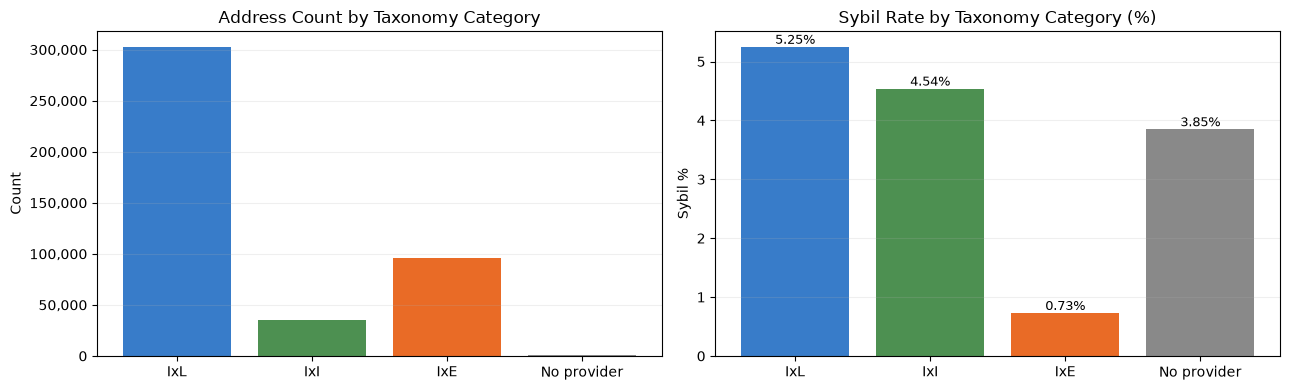

In [14]:
# ── Assign taxonomy category ─────────────────────────────────
df = sp.add_category(df)

cat_stats = df.groupby('category').agg(
    Count=('sybil','count'),
    Sybil_n=('sybil','sum'),
    Sybil_pct=('sybil','mean'),
    Avg_chain=('chain_length','mean'),
).round(4)
cat_stats['Pct_of_total'] = (cat_stats['Count'] / len(df) * 100).round(2)
print('Address taxonomy:')
print(cat_stats.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
order = ['IxL','IxI','IxE','No provider']
counts = [cat_stats.loc[c,'Count'] if c in cat_stats.index else 0 for c in order]
syb_pct= [cat_stats.loc[c,'Sybil_pct']*100 if c in cat_stats.index else 0 for c in order]

x = np.arange(len(order))
axes[0].bar(x, counts, color=['#1565C0','#2E7D32','#E65100','#757575'], alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(order)
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_: f'{int(v):,}'))
axes[0].set(title='Address Count by Taxonomy Category', ylabel='Count')
axes[0].grid(axis='y', alpha=0.2)

axes[1].bar(x, syb_pct, color=['#1565C0','#2E7D32','#E65100','#757575'], alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(order)
axes[1].set(title='Sybil Rate by Taxonomy Category (%)', ylabel='Sybil %')
for xi, v in zip(x, syb_pct): axes[1].text(xi, v+0.05, f'{v:.2f}%', ha='center', fontsize=9)
axes[1].grid(axis='y', alpha=0.2)
plt.tight_layout(); plt.show()

## Funding Groups

Wallets funded through the same unlabeled chain share provider and tree feature values
(`provider_*`, `gini_coefficient`, `tree_size`, ...). If such wallets land in both train and
test, test performance partly measures recognition of clusters already seen in training
(relational leakage). The group split keeps each cluster in one partition.

**Group key**: walk the provision map upward from each address until the next hop is a labeled
anchor, there is no further provider, or a cycle. The last unlabeled node reached is the group
root.

- An address funded directly by a labeled entity (IxL) or with no provider is its own root, so a
  CEX hot wallet never merges its customers into one giant group.
- Grouping by the immediate provider would be wrong for the same reason.

In [15]:
# ── Funding group = root of the unlabeled part of the provision chain ──
df = sp.add_funding_group(df, tfm, labeled_anchors)
gs = df.groupby('funding_group')['sybil'].agg(['size', 'sum'])
multi = gs['size'] > 1
print(f'Funding groups            : {len(gs):,}')
print(f'Multi-wallet groups       : {multi.sum():,}  (largest: {gs["size"].max():,} wallets)')
print(f'Addresses in multi groups : {gs.loc[multi, "size"].sum():,}')
print(f'Sybils in multi groups    : {gs.loc[multi, "sum"].sum():,} / {df.sybil.sum():,}')
print('\nWallets in multi-wallet groups, by category:')
print(df[df['funding_group'].map(gs['size']) > 1]['category'].value_counts().to_string())

Funding groups            : 367,923
Multi-wallet groups       : 22,912  (largest: 2,103 wallets)
Addresses in multi groups : 89,776
Sybils in multi groups    : 2,359 / 18,211

Wallets in multi-wallet groups, by category:


category
IxE            41903
IxI            35037
IxL            12780
No provider       56


## Train / Validation / Test Split

**Split ratios** (paper Table 1): test 30 %, validation 21 %, train 49 %.

**Split method** (`SPLIT_METHOD`):
- `group` (default): stratified group split on the funding group above. No group spans two
  partitions. Multi-wallet groups are placed first, largest first, into the partition whose
  per-class quota is least filled; singletons then fill the remaining per-class quotas at random.
- `random`: the address-level stratified split used in the original paper, kept for comparison.

**Class imbalance handling**: random oversampling of the Sybil class in the training partition
only, to 1:1. Validation and test keep the original ~4.2 % Sybil rate, so reported metrics reflect
real-world conditions.

> Upsampling is applied **after** splitting, to the training partition only, so duplicated Sybil
> rows never appear in validation or test.

In [16]:
S = sp.make_splits(df, FEATS, method=SPLIT_METHOD, seed=SEED)
X_train, y_train = S['X_train'], S['y_train']
X_val,   y_val   = S['X_val'],   S['y_val']
X_test,  y_test  = S['X_test'],  S['y_test']

print(f'Split method: {SPLIT_METHOD}\n')
print('Split summary (before upsampling):')
print(sp.split_summary(df, S).to_string(index=False))
n_syb_tr = int(df.loc[S['idx_train'], 'sybil'].sum())
print(f'\nTrain after upsampling : {len(X_train):,} rows  Sybil={y_train.mean()*100:.1f}%')
print(f'Upsample factor        : {(len(S["idx_train"]) - n_syb_tr) / n_syb_tr:.1f}×')

Split method: group

Split summary (before upsampling):
     Split  Total  Sybil  NonSybil  SybilPct
     Train 213046   8924    204122      4.19
Validation  91305   3824     87481      4.19
      Test 130436   5463    124973      4.19

Train after upsampling : 408,244 rows  Sybil=50.0%
Upsample factor        : 22.9×


In [17]:
# ── Leakage check: row overlap and funding-group overlap ──────
# Row overlap must be 0 under both methods (asserted). Group overlap measures
# relational leakage: test wallets whose funding cluster also appears in train.
# Both methods are reported so the comparison can go in the paper.
leak = {}
for m in sp.SPLIT_METHODS:
    print(f'── {m} ──')
    s_m = S if m == SPLIT_METHOD else sp.make_splits(df, FEATS, method=m, seed=SEED)
    leak[m] = sp.leakage_report(df, s_m)
    print()

── random ──


Split method: random
Row overlap (train/val, train/test, val/test): 0, 0, 0
Test addresses sharing a funding group with a train address: 20,891 / 130,437
Test Sybils sharing a funding group with a train Sybil:     608 / 5,463

── group ──


Split method: group
Row overlap (train/val, train/test, val/test): 0, 0, 0
Test addresses sharing a funding group with a train address: 0 / 130,436
Test Sybils sharing a funding group with a train Sybil:     0 / 5,463



## Exploratory Data Analysis

Compare feature distributions between Sybil and Non-Sybil addresses. Label-based EDA uses the
**training partition only** (before upsampling), so nothing here looks at validation or test labels.

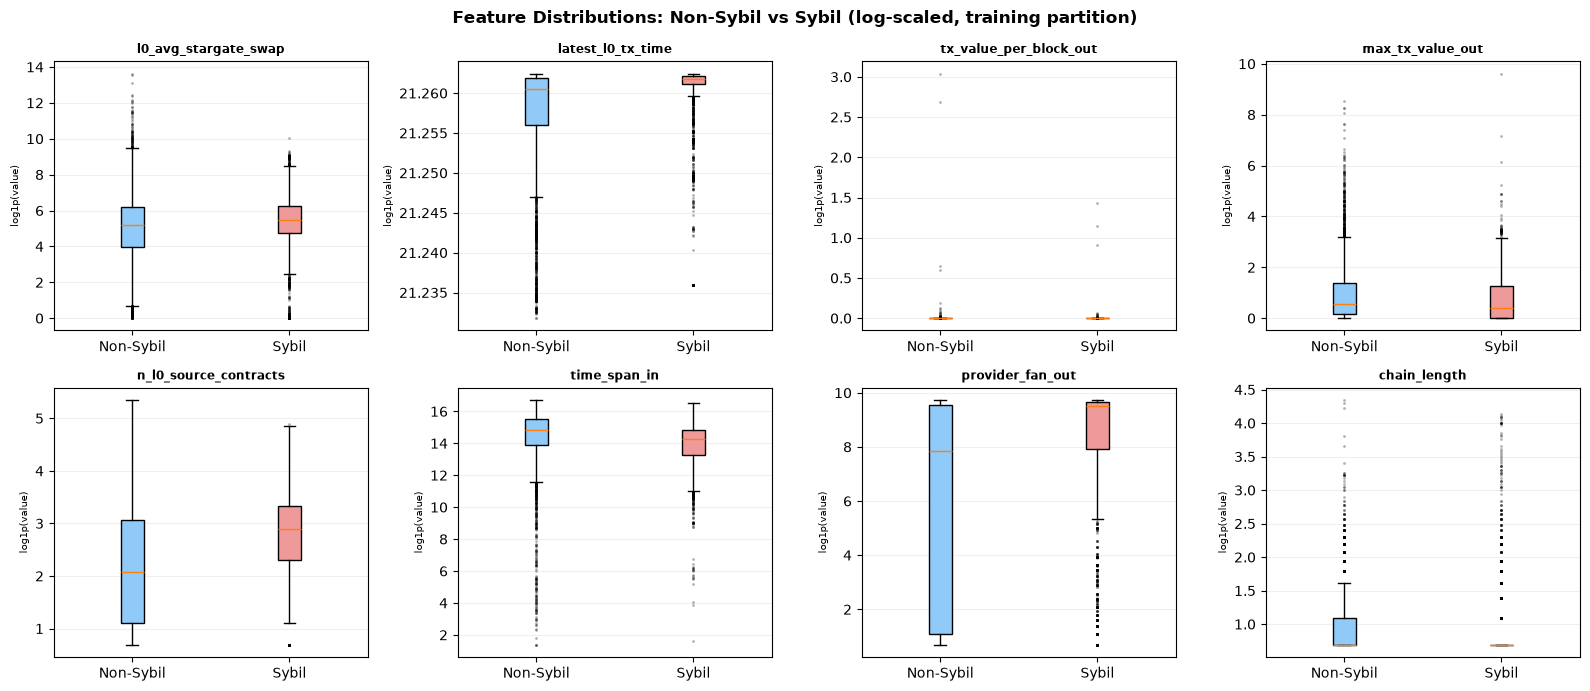

In [18]:
eda = df.loc[S['idx_train']]   # training partition only
# ── Log-scaled box plots: top 8 features ─────────────────────
top_feats = [
    'l0_avg_stargate_swap','latest_l0_tx_time','tx_value_per_block_out',
    'max_tx_value_out','n_l0_source_contracts','time_span_in',
    'provider_fan_out','chain_length',
]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for ax, feat in zip(axes, top_feats):
    sybil_vals = eda[eda.sybil==1][feat].replace(0, np.nan).dropna()
    clean_vals = eda[eda.sybil==0][feat].replace(0, np.nan).dropna()
    # Log1p transform to handle zeros
    data = [np.log1p(clean_vals.sample(min(5000,len(clean_vals)), random_state=42)),
            np.log1p(sybil_vals.sample(min(5000,len(sybil_vals)), random_state=42))]
    bp = ax.boxplot(data, patch_artist=True, notch=False,
                    flierprops=dict(marker='.', markersize=2, alpha=0.3))
    ax.set_xticks([1, 2], ['Non-Sybil', 'Sybil'])   # boxplot(labels=) removed in matplotlib 3.10
    bp['boxes'][0].set_facecolor('#90CAF9'); bp['boxes'][1].set_facecolor('#EF9A9A')
    ax.set_title(feat, fontsize=8.5, fontweight='bold')
    ax.set_ylabel('log1p(value)', fontsize=7.5)
    ax.grid(axis='y', alpha=0.2)

plt.suptitle('Feature Distributions: Non-Sybil vs Sybil (log-scaled, training partition)', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

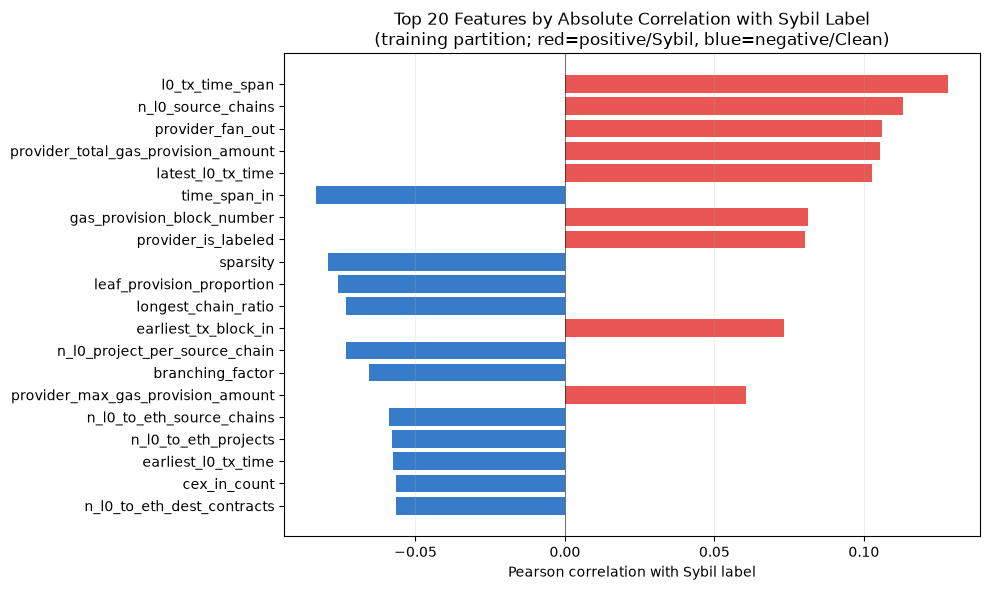

In [19]:
eda = df.loc[S['idx_train']]   # training partition only
# ── Correlation with Sybil label (top 20 by absolute value) ──
corr = eda[FEATS + ['sybil']].corr()['sybil'].drop('sybil')
corr_sorted = corr.abs().sort_values(ascending=False).head(20)
labels = corr_sorted.index
values = corr.loc[labels]

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#E53935' if v > 0 else '#1565C0' for v in values]
ax.barh(labels[::-1], values[::-1], color=colors[::-1], alpha=0.85)
ax.axvline(0, color='black', lw=0.8, alpha=0.5)
ax.set(xlabel='Pearson correlation with Sybil label',
       title='Top 20 Features by Absolute Correlation with Sybil Label\n'
                '(training partition; red=positive/Sybil, blue=negative/Clean)')
ax.grid(axis='x', alpha=0.2)
plt.tight_layout(); plt.show()

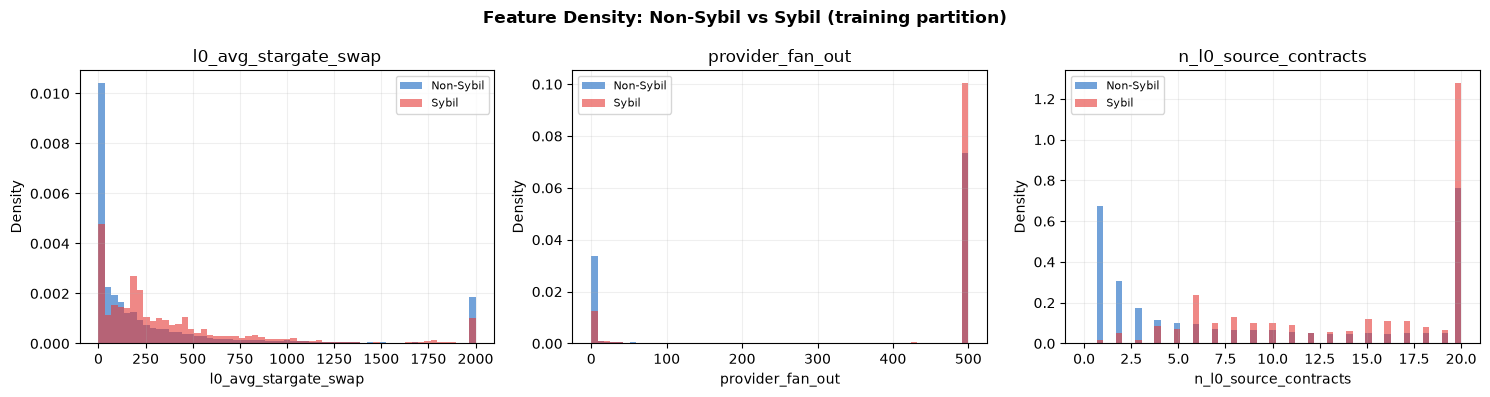

In [20]:
eda = df.loc[S['idx_train']]   # training partition only
# ── Score distribution for continuous top features ─────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, feat, xmax in [
    (axes[0], 'l0_avg_stargate_swap', 2000),
    (axes[1], 'provider_fan_out',     500),
    (axes[2], 'n_l0_source_contracts', 20),
]:
    bins = np.linspace(0, xmax, 60)
    ax.hist(eda[eda.sybil==0][feat].clip(upper=xmax), bins=bins, density=True,
            alpha=0.6, color='#1565C0', label='Non-Sybil')
    ax.hist(eda[eda.sybil==1][feat].clip(upper=xmax), bins=bins, density=True,
            alpha=0.6, color='#E53935', label='Sybil')
    ax.set(xlabel=feat, ylabel='Density', title=feat)
    ax.legend(fontsize=8); ax.grid(alpha=0.2)
plt.suptitle('Feature Density: Non-Sybil vs Sybil (training partition)', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## Export

Saves the master DataFrame and prepared NumPy splits so model notebooks can load them
without re-running the full pipeline (which takes ~25 seconds).

In [21]:
# ── Save master DataFrame (parquet for efficiency) ────────────
master_path = os.path.join(OUTPUT_DIR, 'master_df.parquet')
df.to_parquet(master_path, index=False)
size_mb = os.path.getsize(master_path) / 1e6
print(f'master_df.parquet  saved  ({size_mb:.1f} MB)')

# ── Save feature list ─────────────────────────────────────────
feat_path = os.path.join(OUTPUT_DIR, 'feature_list.json')
with open(feat_path, 'w') as f:
    json.dump(FEATS, f, indent=2)
print(f'feature_list.json  saved  ({len(FEATS)} features)')

# ── Save splits as NumPy arrays ───────────────────────────────
splits_path = os.path.join(OUTPUT_DIR, 'splits.npz')
np.savez_compressed(
    splits_path,
    X_train=X_train.values, y_train=y_train.values,
    X_val  =X_val.values,   y_val  =y_val.values,
    X_test =X_test.values,  y_test =y_test.values,
    idx_train=S['idx_train'], idx_val=S['idx_val'], idx_test=S['idx_test'],
    split_method=np.array(SPLIT_METHOD),
)
size_mb_sp = os.path.getsize(splits_path) / 1e6
print(f'splits.npz         saved  ({size_mb_sp:.1f} MB)')

# ── Dataset statistics for the paper (Tables 1, 5, 12) ─────────
cat = df.groupby('category')['sybil'].agg(n='size', sybil='sum')
splits_by_method = {m: sp.split_summary(df, S if m == SPLIT_METHOD else sp.make_splits(df, FEATS, method=m, seed=SEED))
                        .set_index('Split').to_dict('index') for m in sp.SPLIT_METHODS}
sp.save_results([], '00_data_pipeline', SPLIT_METHOD, leakage=leak, extra=dict(
    n_addresses=len(df), n_sybil=int(df.sybil.sum()),
    provision_edges_after_cutoff=funding.attrs['n_after_cutoff'],
    categories={k: {kk: int(vv) for kk, vv in v.items()} for k, v in cat.to_dict('index').items()},
    splits=splits_by_method,
    funding_groups=dict(n=int(len(gs)), multi_wallet=int(multi.sum()), largest=int(gs['size'].max()),
                        sybils_in_multi=int(gs.loc[multi, 'sum'].sum())),
))

print()
print('=== Reload example ===')
print("splits = np.load('output/splits.npz')")
print("X_train = splits['X_train'];  y_train = splits['y_train']")
print("# ... etc.")
print()
print('Pipeline complete ✓')

master_df.parquet  saved  (143.3 MB)
feature_list.json  saved  (63 features)


splits.npz         saved  (40.7 MB)
Saved results/00_data_pipeline_group.json

=== Reload example ===
splits = np.load('output/splits.npz')
X_train = splits['X_train'];  y_train = splits['y_train']
# ... etc.

Pipeline complete ✓


## Loading Pre-Built Splits in Model Notebooks

If you have already run this pipeline, the model notebooks can skip the 25-second
data loading step by loading the saved splits directly:

```python
import numpy as np, json

splits  = np.load('output/splits.npz')
X_train = splits['X_train'];  y_train = splits['y_train']
X_val   = splits['X_val'];    y_val   = splits['y_val']
X_test  = splits['X_test'];   y_test  = splits['y_test']

with open('output/feature_list.json') as f:
    FEATS = json.load(f)
```

Alternatively, load the full master DataFrame for custom splits or further EDA:

```python
import pandas as pd
df = pd.read_parquet('output/master_df.parquet')
```